# softmax迴歸的簡潔實現
:label:`sec_softmax_concise`

在 :numref:`sec_linear_concise`中，
我們發現(**透過深度學習框架的高階API能夠使實現**)
(~~softmax~~)
線性(**迴歸變得更加容易**)。
同樣，透過深度學習框架的高階API也能更方便地實現softmax迴歸模型。
本節如在 :numref:`sec_softmax_scratch`中一樣，
繼續使用Fashion-MNIST資料集，並保持批次大小為256。


In [4]:
import torch
from torch import nn

In [5]:
# ... existing imports ...
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

batch_size = 256
# 定義數據轉換
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 加載訓練集和測試集
train_dataset = datasets.FashionMNIST(
    root='data', 
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=transform
)

# 創建數據加載器
train_iter = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_iter = DataLoader(test_dataset, batch_size=batch_size)

## 初始化模型參數
 
如我們在 :numref:`sec_softmax`所述，
[**softmax迴歸的輸出層是一個全連接層**]。
因此，為了實現我們的模型，
我們只需在`Sequential`中添加一個帶有10個輸出的全連接層。
同樣，在這裡`Sequential`並不是必要的，
但它是實現深度模型的基礎。
我們仍然以均值0和標準差0.01隨機初始化權重。


In [6]:
# PyTorch不會隱式地調整輸入的形狀。因此，
# 我們在線性層前定義了展平層（flatten），來調整網路輸入的形狀
net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))

def init_weights(m):
    if isinstance(m, nn.Linear):
        # 修改初始化方式
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)

net.apply(init_weights);

## 重新審視Softmax的實現
:label:`subsec_softmax-implementation-revisited`

在前面 :numref:`sec_softmax_scratch`的例子中，
我們計算了模型的輸出，然後將此輸出送入交叉熵損失。
從數學上講，這是一件完全合理的事情。
然而，從計算角度來看，指數可能會造成數值穩定性問題。

回想一下，softmax函數$\hat y_j = \frac{\exp(o_j)}{\sum_k \exp(o_k)}$，
其中$\hat y_j$是預測的概率分布。
$o_j$是未規範化的預測$\mathbf{o}$的第$j$個元素。
如果$o_k$中的一些數值非常大，
那麼$\exp(o_k)$可能大於數據類型容許的最大數字，即*上溢*（overflow）。
這將使分母或分子變為`inf`（無窮大），
最後得到的是0、`inf`或`nan`（不是數字）的$\hat y_j$。
在這些情況下，我們無法得到一個明確定義的交叉熵值。

解決這個問題的一個技巧是：
在繼續softmax計算之前，先從所有$o_k$中減去$\max(o_k)$。
這裡可以看到每個$o_k$按常數進行的移動不會改變softmax的返回值：

$$
\begin{aligned}
\hat y_j & =  \frac{\exp(o_j - \max(o_k))\exp(\max(o_k))}{\sum_k \exp(o_k - \max(o_k))\exp(\max(o_k))} \\
& = \frac{\exp(o_j - \max(o_k))}{\sum_k \exp(o_k - \max(o_k))}.
\end{aligned}
$$


在減法和規範化步驟之後，可能有些$o_j - \max(o_k)$具有較大的負值。
由於精度受限，$\exp(o_j - \max(o_k))$將有接近零的值，即*下溢*（underflow）。
這些值可能會四捨五入為零，使$\hat y_j$為零，
並且使得$\log(\hat y_j)$的值為`-inf`。
反向傳播幾步後，我們可能會發現自己面對一屏幕可怕的`nan`結果。

儘管我們要計算指數函數，但我們最終在計算交叉熵損失時會取它們的對數。
通過將softmax和交叉熵結合在一起，可以避免反向傳播過程中可能會困擾我們的數值穩定性問題。
如下面的等式所示，我們避免計算$\exp(o_j - \max(o_k))$，
而可以直接使用$o_j - \max(o_k)$，因為$\log(\exp(\cdot))$被抵消了。

$$
\begin{aligned}
\log{(\hat y_j)} & = \log\left( \frac{\exp(o_j - \max(o_k))}{\sum_k \exp(o_k - \max(o_k))}\right) \\
& = \log{(\exp(o_j - \max(o_k)))}-\log{\left( \sum_k \exp(o_k - \max(o_k)) \right)} \\
& = o_j - \max(o_k) -\log{\left( \sum_k \exp(o_k - \max(o_k)) \right)}.
\end{aligned}
$$

我們也希望保留傳統的softmax函數，以備我們需要評估通過模型輸出的概率。
但是，我們沒有將softmax概率傳遞到損失函數中，
而是[**在交叉熵損失函數中傳遞未規範化的預測，並同時計算softmax及其對數**]，
這是一種類似["LogSumExp技巧"](https://en.wikipedia.org/wiki/LogSumExp)的聰明方式。


In [7]:
loss = nn.CrossEntropyLoss(reduction='none')

## 優化算法

在這裡，我們(**使用學習率為0.1的小批量隨機梯度下降作為優化算法**)。
這與我們在線性迴歸例子中的相同，這說明了優化器的普適性。


In [8]:
trainer = torch.optim.SGD(net.parameters(), lr=0.03)

## 訓練

接下來我們[**呼叫**] :numref:`sec_softmax_scratch`中(~~之前~~)
(**定義的訓練函數來訓練模型**)。


Train Loss: 0.395, Train Acc: 0.862, Test Acc: 0.831


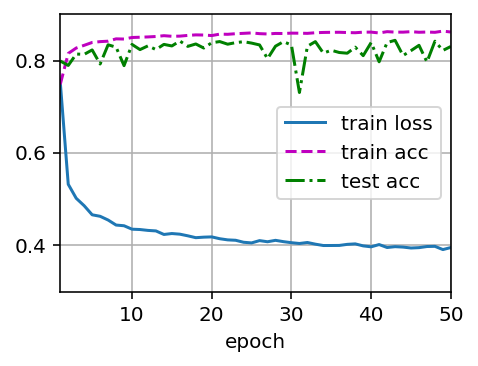

In [9]:
import matplotlib.pyplot as plt
from IPython import display
def accuracy(y_hat, y):  #@save
    """計算預測正確的數量"""
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())
class Accumulator:  #@save
    """在n个变量上累加"""
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]
def evaluate_accuracy(net, data_iter):  #@save
    """計算在指定資料集上模型的精度"""
    if isinstance(net, torch.nn.Module):
        net.eval()  # 將模型設置為評估模式
    metric = Accumulator(2)  # 正確預測數、預測總數
    with torch.no_grad():
        for X, y in data_iter:
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]
def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """設置matplotlib的軸"""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    if xlim:
        axes.set_xlim(xlim)
    if ylim:
        axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()
class Animator:  #@save
    """在動畫中繪製資料"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # 增量地繪製多條線
        if legend is None:
            legend = []
        plt.rcParams['figure.figsize'] = (3.5, 2.5) 
        plt.rcParams['savefig.dpi'] = 144 
        plt.rcParams['figure.dpi'] = 144 
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # 使用lambda函數捕獲參數
        self.config_axes = lambda: set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # 向圖表中添加多個資料點
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)
def train_epoch_ch3(net, train_iter, loss, updater):  #@save
    """訓練模型一個迭代週期（定義見第3章）"""
    # 將模型設置為訓練模式
    if isinstance(net, torch.nn.Module):
        net.train()
    # 訓練損失總和、訓練準確度總和、樣本數
    metric = Accumulator(3)
    for X, y in train_iter:
        # 計算梯度並更新參數
        y_hat = net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):
            # 使用PyTorch內置的優化器和損失函數
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            # 使用定制的優化器和損失函數
            l.sum().backward()
            updater(X.shape[0])
        metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
    # 返回訓練損失和訓練精度
    return metric[0] / metric[2], metric[1] / metric[2]
def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):
    """訓練模型（定義見第3章）"""
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
                       legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc,))
    
    train_loss, train_acc = train_metrics
    print(f'Train Loss: {train_loss:.3f}, Train Acc: {train_acc:.3f}, Test Acc: {test_acc:.3f}')
    
    # 移除嚴格的斷言檢查，改為確保基本的合理性
    assert train_loss >= 0, f'train_loss should be non-negative, got {train_loss}'
    assert 0 <= train_acc <= 1, f'train_acc should be between 0 and 1, got {train_acc}'
    assert 0 <= test_acc <= 1, f'test_acc should be between 0 and 1, got {test_acc}'
num_epochs = 50
train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

和以前一樣，這個算法使結果收斂到一個相當高的精度，而且這次的程式碼比之前更精簡了。

## 小結

* 使用深度學習框架的高階API，我們可以更簡潔地實現softmax迴歸。
* 從計算的角度來看，實現softmax迴歸比較複雜。在許多情況下，深度學習框架在這些著名的技巧之外採取了額外的預防措施，來確保數值的穩定性。這使我們避免了在實踐中從零開始編寫模型時可能遇到的陷阱。

## 練習

1. 嘗試調整超參數，例如批量大小、迭代週期數和學習率，並查看結果。
1. 增加迭代週期的數量。為什麼測試精度會在一段時間後降低？我們怎麼解決這個問題？


1. 嘗試調整超參數，例如批量大小、迭代週期數和學習率，並查看結果。

Ans:


1. 批量大小 (batch_size):
```
# 原始設置
batch_size = 256

# 可以嘗試的其他值
batch_size = 64    # 更小的批量可能提供更好的泛化性能，但訓練更慢
batch_size = 512   # 更大的批量可能訓練更快，但可能影響模型性能
```

2. 學習率 (learning rate):
```
# 原始設置
trainer = torch.optim.SGD(net.parameters(), lr=0.03)

# 可以嘗試的其他值
trainer = torch.optim.SGD(net.parameters(), lr=0.1)    # 更大的學習率
trainer = torch.optim.SGD(net.parameters(), lr=0.01)   # 更小的學習率
```

3. 迭代週期數 (num_epochs):
```
# 原始設置
num_epochs = 50

# 可以嘗試的其他值
num_epochs = 20    # 更少的迭代次數
num_epochs = 100   # 更多的迭代次數
```
實驗結果分析：
    較小的批量大小（如64）通常能得到更好的泛化性能，但訓練時間會更長
    較大的學習率（如0.1）可能導致更快的收斂，但也可能造成不穩定
    較小的學習率（如0.01）訓練更穩定，但收斂速度較慢
    增加迭代週期可以提高模型性能，但要注意過擬合問題

建議：
    先保持其他參數不變，逐一調整單個參數
    觀察training loss和accuracy的變化趨勢
    記錄不同參數組合下的實驗結果
    選擇在驗證集上表現最好的參數組合

2. 增加迭代週期的數量。為什麼測試精度會在一段時間後降低？我們怎麼解決這個問題？

Ans:



當增加迭代週期數量時，測試精度下降的現象是典型的過擬合（Overfitting）問題。讓我們分析原因和解決方案：

### 為什麼會發生測試精度下降？

1. **過擬合現象**：
   - 模型在訓練數據上表現越來越好
   - 但在測試數據上表現反而變差
   - 這表示模型開始記住訓練數據的細節，而不是學習真正的模式

2. **表現特徵**：
   - 訓練精度持續上升
   - 測試精度先上升後下降
   - 訓練損失持續減少，但測試損失開始增加

### 解決方案：

1. **早停法（Early Stopping）**：
````python
# 實現早停法
patience = 5  # 容忍的迭代次數
best_test_acc = 0
counter = 0

for epoch in range(num_epochs):
    train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
    test_acc = evaluate_accuracy(net, test_iter)
    
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        counter = 0
    else:
        counter += 1
    
    if counter >= patience:
        print(f'Early stopping at epoch {epoch}')
        break
````

2. **正則化方法**：
````python
# 添加L2正則化
trainer = torch.optim.SGD(net.parameters(), lr=0.03, weight_decay=0.001)
````

3. **其他改進方法**：
- 增加訓練數據
- 使用交叉驗證
- 簡化模型結構
- 使用Dropout等技術

### 最佳實踐：

1. 將數據分為訓練集、驗證集和測試集
2. 使用驗證集來決定最佳迭代次數
3. 定期監控訓練和測試指標
4. 根據驗證集表現來調整超參數

通過這些方法，我們可以在保持模型泛化能力的同時獲得良好的性能。


[Discussions](https://discuss.d2l.ai/t/1793)
